In [ ]:
import geopandas as gpd

local = gpd.read_file(r'data/result4/shapley.shp')

local.rename(columns={
    'Precipitat': 'Precipitation',
    'PctOlderAd': 'PctOlderAdult',
    'PctSeconda': 'PctSecondary',
    'PctTertiar': 'PctTertiary'
}, inplace=True)

local

,LST,Precipitation,Sunset,GDP,PctOlderAdult,PctPrimary,PctSecondary,PctTertiary,city,NPI,geometry
0,14.030502,1.249600,-0.691108,-0.682697,-0.744787,0.391987,-0.279263,-0.530572,梅州,132,"POLYGON Z ((3172852.759 3024945.608 0, 3173559..."
1,-2.852260,-1.776791,3.093884,-0.859838,2.129150,-0.156713,0.113718,-0.223028,吕梁,120,"POLYGON Z ((2352673.622 4507687.604 0, 2353099..."
2,-1.988954,0.519215,-4.337643,-1.088534,-3.386105,-0.797914,-0.053131,-0.306151,舟山,102,"MULTIPOLYGON Z (((3704161.177 3765051.612 0, 3..."
3,-3.787508,-1.932785,-3.453215,-2.403144,-2.339932,-0.409068,-0.191092,-0.788796,朝阳,101,"POLYGON Z ((2947975.461 5128461.903 0, 2949669..."
4,2.091036,0.857099,3.517734,-1.342516,-4.020154,0.261969,-0.061946,-0.548795,广安,119,"MULTIPOLYGON Z (((2171518.404 3492793.408 0, 2..."
...,...,...,...,...,...,...,...,...,...,...,...
271,-3.189105,-2.872347,3.564607,-2.244350,0.834943,-0.197214,-0.272199,-0.431983,陇南,111,"POLYGON Z ((1905316.581 3929585.263 0, 1905738..."
272,-2.383802,-0.502983,3.133047,-0.951753,1.435568,0.238245,-0.019647,-0.282083,保山,119,"POLYGON Z ((1376855.172 2886172.787 0, 1375642..."
273,2.277760,0.678648,3.125844,-1.285841,-3.832411,0.272799,-0.231216,-0.467808,遂宁,117,"MULTIPOLYGON Z (((2036812.985 3483897.241 0, 2..."
274,-3.196391,0.521652,-1.321926,0.238201,1.402803,-0.330734,0.108064,0.666379,合肥,117,"POLYGON Z ((3094538.255 3947390.977 0, 3095675..."


In [ ]:
import pandas as pd

NPI = pd.read_csv(r'data/result2/data_手动修正.csv', index_col='Unnamed: 0')
NPI.rename(columns={
    'time': 'NPI',
}, inplace=True)
NPI

,city,intensity,umap_1,umap_2,NPI,log_intensity,quartile,color,city_en
0,梅州,13170,3.175451,6.958565,132,4.119586,Q2,#2ca02c,Meizhou
1,吕梁,17040,2.973684,3.357782,120,4.231470,Q2,#2ca02c,Luliang
2,舟山,31566,5.663746,-0.090759,102,4.499220,Q3,#ff7f0e,Zhoushan
3,朝阳,7912,2.659808,1.873272,101,3.898286,Q1,#1f77b4,Chaoyang
4,广安,6443,3.196313,6.344944,119,3.809088,Q1,#1f77b4,Guang'an
...,...,...,...,...,...,...,...,...,...
271,陇南,7059,4.239348,5.974148,111,3.848743,Q1,#1f77b4,Longnan
272,保山,11598,6.201652,4.471026,119,4.064383,Q2,#2ca02c,Baoshan
273,遂宁,7474,1.444519,3.866109,117,3.873553,Q1,#1f77b4,Suining
274,合肥,167171,2.367577,6.124521,117,5.223161,Q4,#d62728,Hefei


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import ParameterSampler
from mpl_toolkits.mplot3d import Axes3D
import random


features = NPI[['intensity', 'umap_1', 'umap_2']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


param_dist = {
    "n_clusters": list(range(2, 11))
}

best_score = -1
best_kmeans = None
random.seed(42)
n_iter = 20

for params in ParameterSampler(param_dist, n_iter=n_iter, random_state=42):
    kmeans = KMeans(n_clusters=params["n_clusters"], random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_kmeans = kmeans
        best_labels = labels

print(f"最佳聚类数: {best_kmeans.n_clusters}，轮廓系数: {best_score:.3f}")

NPI['cluster'] = best_labels




d:\Anaconda\envs\LLM\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


最佳聚类数: 6，轮廓系数: 0.436


In [ ]:
from scipy.spatial.distance import cdist

cluster_centers = NPI.groupby('cluster')[['umap_2', 'umap_1']].mean()

closest_cities = []

for cluster_id, center in cluster_centers.iterrows():
    cluster_data = NPI[NPI['cluster'] == cluster_id].copy()
    
    distances = cdist(cluster_data[['umap_2', 'umap_1']], [center])
    
    min_index = distances.argmin()
    closest_city = cluster_data.iloc[min_index]
    
    closest_cities.append({
        'cluster': cluster_id,
        'city_en': closest_city['city_en'],
        'distance': distances[min_index][0]
    })

closest_df = pd.DataFrame(closest_cities)
print(closest_df)


   cluster    city_en  distance
0        0    Jiamusi  0.205289
1        1  Zhumadian  0.232282
2        2     Diqing  0.158132
3        3    Beijing  0.528286
4        4      Hefei  0.166005
5        5    Taizhou  0.017422


C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_2592\3675292508.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Spectral')
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


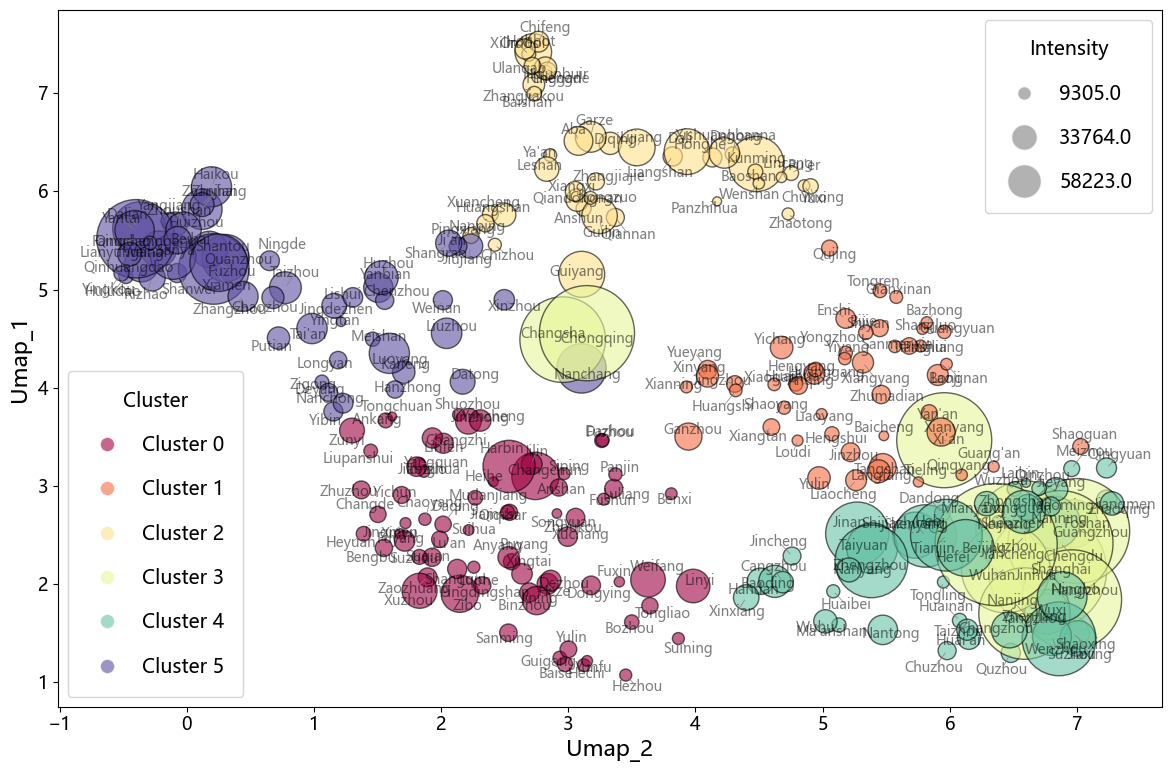

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from adjustText import adjust_text
from matplotlib.cm import get_cmap

plt.rcParams.update({
    'font.family': 'Microsoft YaHei',
    'font.size': 16,
    'axes.labelsize': 16,
    'legend.fontsize': 14,
    'legend.title_fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
})

NUM_CLUSTERS = 6
cmap = get_cmap('Spectral')
colors = [cmap(i) for i in np.linspace(0, 1, NUM_CLUSTERS)]
NPI['cluster_color'] = NPI['cluster'].apply(lambda x: colors[int(x) % NUM_CLUSTERS])

plt.figure(figsize=(12, 8))
scale = 0.01

sc = plt.scatter(
    NPI['umap_2'],
    NPI['umap_1'],
    c=NPI['cluster_color'],
    s=NPI['intensity'] * scale,
    alpha=0.6,
    edgecolors='black',
    linewidths=1,
    rasterized=True
)

texts = [
    plt.text(row['umap_2'], row['umap_1'], row['city_en'], fontsize=10, ha='center', va='center', alpha=0.5)
    for _, row in NPI.iterrows()
]

adjust_text(
    texts,
    only_move={'points': 'y', 'texts': 'xy'},
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
    expand_text=(1.2, 1.2),
    expand_points=(1.2, 1.2)
)

cluster_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[i], markersize=10, alpha=0.6,
           markeredgecolor='w', markeredgewidth=0.5,
           label=f'Cluster {i}')
    for i in range(NUM_CLUSTERS)
]

cluster_legend = plt.legend(
    handles=cluster_handles,
    title='Cluster',
    loc='lower left',
    borderpad=1,
    labelspacing=1.2,
    markerscale=1
)
plt.gca().add_artist(cluster_legend)

size_legend_vals = np.linspace(NPI['intensity'].quantile(0.2), NPI['intensity'].quantile(0.8), 3)
size_handles = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.1f}',
           markerfacecolor='gray', markersize=np.sqrt(val * scale), alpha=0.6)
    for val in size_legend_vals
]

plt.legend(
    handles=size_handles,
    title='Intensity',
    loc='upper right',
    borderpad=1,
    labelspacing=1.2,
    markerscale=1
)

plt.xlim(left=NPI['umap_2'].min() - 0.5)
plt.xlabel('Umap_2')
plt.ylabel('Umap_1')
plt.tight_layout()
# plt.savefig('plot/driving/cluster.png', bbox_inches='tight', dpi=300)
plt.show()


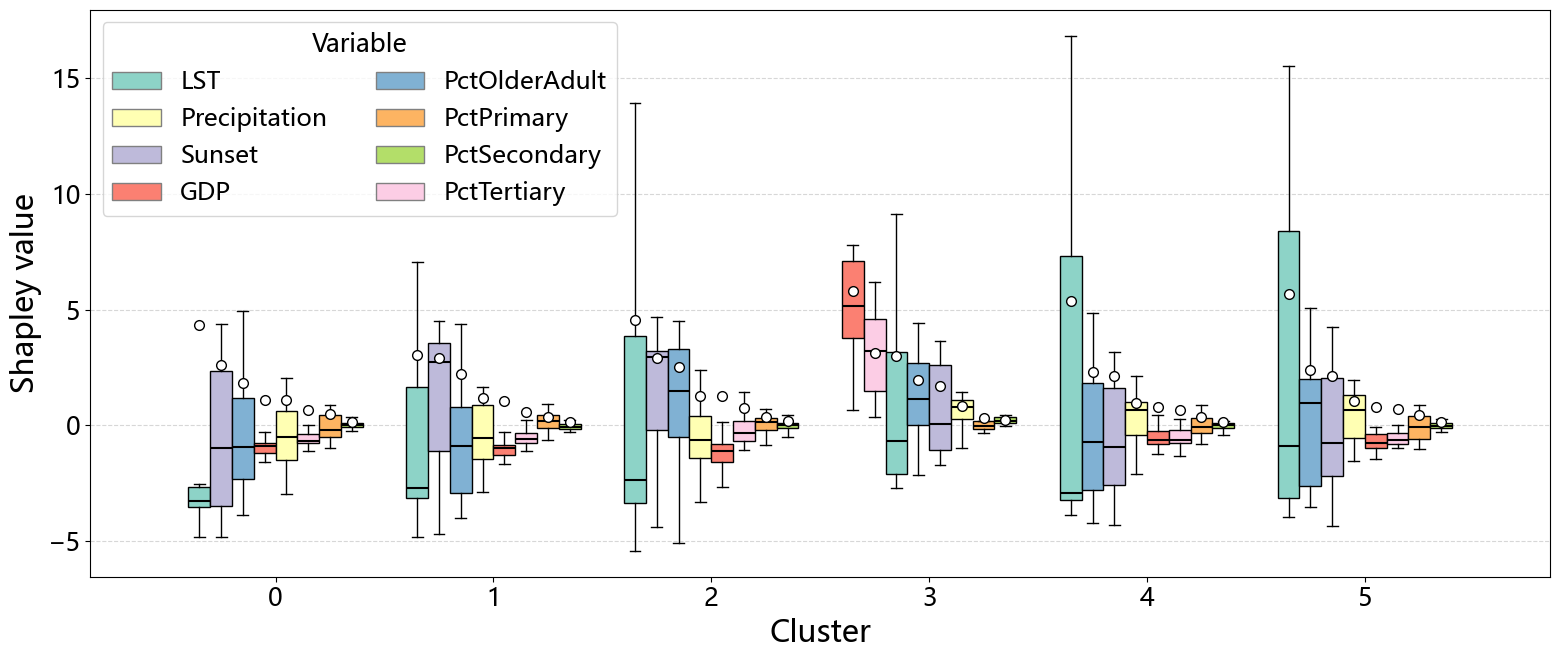

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.family': 'Microsoft YaHei',
    'font.size': 20,
    'axes.labelsize': 22,
    'legend.fontsize': 17.5,
    'legend.title_fontsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
})

df = local.copy()

features = ['LST', 'Precipitation', 'Sunset', 'GDP', 'PctOlderAdult', 'PctPrimary', 'PctSecondary', 'PctTertiary']#, 'GEO']
df_abs = df.copy()
df_abs[features] = df_abs[features]
df_abs = df_abs.merge(NPI[['city', 'cluster']], on='city', how='left')

df_long = df_abs.melt(
    id_vars='cluster',
    value_vars=features,
    var_name='feature',
    value_name='shapley'
)

fig, ax = plt.subplots(figsize=(16, 7))
unique_clusters = sorted(df_long['cluster'].unique())
n_features = len(features)
group_width = 0.8  
box_width = group_width / n_features 

colors = sns.color_palette('Set3', n_colors=n_features)
color_map = dict(zip(features, colors))

for cluster_id in unique_clusters:
    df_cluster = df_long[df_long['cluster'] == cluster_id]
    
    sort_metric = df_cluster.groupby('feature')['shapley'].apply(lambda x: x.abs().mean())
    sorted_features_in_cluster = sort_metric.sort_values(ascending=False).index.tolist()
    
    
    for i, feature_name in enumerate(sorted_features_in_cluster):
        position = cluster_id - group_width / 2 + box_width / 2 + i * box_width
        box_data = df_cluster[df_cluster['feature'] == feature_name]['shapley']
        

        bplot = ax.boxplot(
            box_data,
            positions=[position],
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", linewidth=1.5) 
        )
        

        for patch in bplot['boxes']:
            patch.set_facecolor(color_map[feature_name])
            mean_abs_value = box_data.abs().mean()
            ax.plot(position, mean_abs_value,
                    marker='o',
                    markersize=7,
                    markerfacecolor='white',
                    markeredgecolor='black',
                    markeredgewidth=1.0,
                    zorder=10)


ax.set_xticks(unique_clusters)
ax.set_xticklabels([str(c) for c in unique_clusters])
ax.set_xlabel('Cluster')
ax.set_ylabel('Shapley value')
ax.grid(axis='y', linestyle='--', alpha=0.5)

legend_patches = [Patch(facecolor=color_map[feature], label=feature, ec='grey') for feature in features]
ax.legend(handles=legend_patches, title='Variable', ncol=2, loc='upper left')

plt.tight_layout()

# plt.savefig('plot/driving/boxplot.png', bbox_inches='tight', dpi=300)
plt.show()


In [38]:
NPI[NPI['cluster']==3]

,city,intensity,umap_1,umap_2,NPI,log_intensity,quartile,color,city_en,cluster,cluster_color
8,深圳,499233,2.551052,6.591249,136,5.698303,Q4,#d62728,Shenzhen,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
15,西安,468115,3.464851,5.956272,133,5.670353,Q4,#d62728,Xi'an,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
98,长沙,379632,4.489350,2.956308,139,5.579363,Q4,#d62728,Changsha,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
110,上海,718749,2.138282,6.769643,143,5.856577,Q4,#d62728,Shanghai,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
130,广州,570431,2.539984,7.001979,145,5.756203,Q4,#d62728,Guangzhou,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
153,成都,573240,2.415458,6.870037,134,5.758336,Q4,#d62728,Chengdu,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
160,杭州,516378,1.840238,6.958532,125,5.712968,Q4,#d62728,Hangzhou,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
182,重庆,469460,4.555193,3.147026,135,5.671599,Q4,#d62728,Chongqing,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
189,武汉,406219,2.157282,6.439533,130,5.608760,Q4,#d62728,Wuhan,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."
193,南京,433466,1.698985,6.587519,125,5.636955,Q4,#d62728,Nanjing,3,"(0.9019607843137256, 0.9607843137254902, 0.596..."


In [ ]:
import pandas as pd
text = pd.read_csv(r"data/result4/activity_type.csv")


In [ ]:
import pandas as pd

df = text.copy()

df['0'] = (df['Review'] == 0).astype(int)


conditions = {
    '0_work':       ((df['Review'] == 0) & (df['content_category'] == 'Work')).astype(int),
    '0_food':       ((df['Review'] == 0) & (df['content_category'] == 'Diet')).astype(int),
    '0_indoor_rec': ((df['Review'] == 0) & (df['content_category'] == 'indoor_Entertainment')).astype(int),
    '0_outdoor_rec':((df['Review'] == 0) & (df['content_category'] == 'outdoor_Entertainment')).astype(int),
    
    '1_work':       ((df['Review'] == 1) & (df['content_category'] == 'Work')).astype(int),
    '1_food':       ((df['Review'] == 1) & (df['content_category'] == 'Diet')).astype(int),
    '1_indoor_rec': ((df['Review'] == 1) & (df['content_category'] == 'indoor_Entertainment')).astype(int),
    '1_outdoor_rec':((df['Review'] == 1) & (df['content_category'] == 'outdoor_Entertainment')).astype(int),

    'Fandom':        (df['content_category'] == 'Star-chasing').astype(int),
    'Emotion_regulation':     (df['content_category'] == 'Emotion-process').astype(int),
    'Other':               (df['content_category'] == 'Other').astype(int)
}


for col, series in conditions.items():
    df[col] = series

feature = df.groupby('city')[['0'] + list(conditions.keys())].mean().reset_index()
feature



# result.to_csv("city_review_statistics.csv", index=False, encoding='utf-8-sig')


,city,0,0_work,0_food,0_indoor_rec,0_outdoor_rec,1_work,1_food,1_indoor_rec,1_outdoor_rec,Fandom,Emotion_regulation,Other
0,三亚,0.321263,0.001855,0.001492,0.015001,0.268721,0.004879,0.016452,0.040929,0.549740,0.013186,0.079802,0.005242
1,三明,0.228188,0.006249,0.008563,0.040731,0.073826,0.017589,0.032631,0.060403,0.314742,0.140014,0.176811,0.122888
2,三门峡,0.180328,0.003883,0.007334,0.035375,0.061691,0.023727,0.042709,0.084987,0.410699,0.030198,0.232097,0.065142
3,上海,0.355760,0.008247,0.004855,0.085107,0.134890,0.024682,0.032207,0.143492,0.259835,0.102900,0.149600,0.052093
4,上饶,0.226571,0.002573,0.003792,0.032774,0.136918,0.014085,0.024783,0.051327,0.534940,0.027221,0.139355,0.031013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,黔东南,0.069252,0.002164,0.000902,0.009017,0.040577,0.008837,0.014067,0.028855,0.765555,0.010460,0.104959,0.013706
272,黔南,0.136127,0.002343,0.001301,0.009630,0.057002,0.015877,0.023686,0.036960,0.598386,0.023686,0.188964,0.041385
273,黔西南,0.156591,0.007976,0.002519,0.033165,0.064232,0.019312,0.023929,0.049958,0.502519,0.037364,0.223342,0.035684
274,齐齐哈尔,0.234838,0.009168,0.006347,0.032793,0.096968,0.017278,0.053597,0.088152,0.311707,0.031382,0.278914,0.073343


In [25]:
feature = feature.merge(NPI[['cluster', 'city', 'intensity']], how='right', on='city')
feature

,city,0,0_work,0_food,0_indoor_rec,0_outdoor_rec,1_work,1_food,1_indoor_rec,1_outdoor_rec,Fandom,Emotion_regulation,Other,cluster,intensity
0,梅州,0.267135,0.007616,0.010252,0.043351,0.123609,0.024897,0.043644,0.072935,0.342121,0.024605,0.228178,0.075864,4,13170
1,吕梁,0.216399,0.019201,0.007784,0.031396,0.072652,0.023612,0.037883,0.069798,0.261806,0.046445,0.291645,0.137519,0,17040
2,舟山,0.189583,0.002981,0.001754,0.016310,0.139425,0.009821,0.017888,0.025956,0.622589,0.013329,0.124518,0.024377,5,31566
3,朝阳,0.189261,0.006911,0.010101,0.028708,0.044657,0.026050,0.044657,0.070707,0.237108,0.036683,0.310473,0.180223,0,7912
4,广安,0.198830,0.005848,0.007443,0.031898,0.067517,0.023923,0.051568,0.080276,0.355130,0.026582,0.259436,0.090377,1,6443
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,陇南,0.196838,0.007649,0.006119,0.018868,0.075472,0.030087,0.021928,0.046915,0.405915,0.031617,0.296277,0.059153,1,7059
272,保山,0.233857,0.005236,0.001745,0.030017,0.144852,0.011169,0.016056,0.045724,0.539267,0.013962,0.152531,0.037347,2,11598
273,遂宁,0.242872,0.010692,0.006110,0.061100,0.070774,0.025967,0.035642,0.090631,0.336049,0.037169,0.243890,0.080448,0,7474
274,合肥,0.299861,0.010766,0.007555,0.051656,0.099723,0.028740,0.048288,0.106617,0.219875,0.074320,0.240494,0.111622,4,167171


In [ ]:
feature.to_csv(r'data/result4/feature.csv', index=False)